In [1]:
import pandas as pd
df = pd.read_csv('D:\TicketingPlatform\data\synthetic_tickets.csv')

In [2]:
df.head()

,ticket_id,description,teams,priority,resolution_time,application,environment,category,status,affected_users,impact_scope,created_at,resolved_at,root_cause
0,1,Batch process terminated unexpectedly reported...,"Batch,Middleware",P3,24,Control-M,Production,Batch Failure,Resolved,33,department,2026-05-28 11:18:18,2026-05-28 11:42:18,Scheduler Failure
1,2,Linux server unreachable reported by a departm...,Unix/Linux,P2,79,Linux ERP Server,UAT,Application,Closed,99,department,2025-11-01 22:04:58,2025-11-01 23:23:58,Kernel Panic
2,3,Firewall blocking traffic affecting one employee.,"Network,Database",P4,16,VPN Gateway,Production,Connectivity,Resolved,2,single_user,2025-11-04 08:55:30,2025-11-04 09:11:30,Network Congestion
3,4,Firewall blocking traffic affecting one employee.,Network,P3,43,VPN Gateway,Production,Connectivity,Resolved,10,single_user,2025-01-28 07:37:13,2025-01-28 08:20:13,VPN Tunnel Failure
4,5,Network latency exceeds threshold reported by ...,Network,P2,188,VPN Gateway,Production,Connectivity,Resolved,59,department,2025-09-05 23:56:14,2025-09-06 03:04:14,VPN Tunnel Failure


In [3]:
df.describe()

,ticket_id,resolution_time,affected_users
count,20000.000000,20000.000000,20000.000000
mean,10000.500000,132.713400,682.055050
std,5773.647028,142.332229,1813.441742
min,1.000000,4.000000,1.000000
25%,5000.750000,41.000000,7.000000
50%,10000.500000,82.000000,46.000000
75%,15000.250000,168.000000,337.000000
max,20000.000000,780.000000,9994.000000


<Axes: xlabel='teams'>

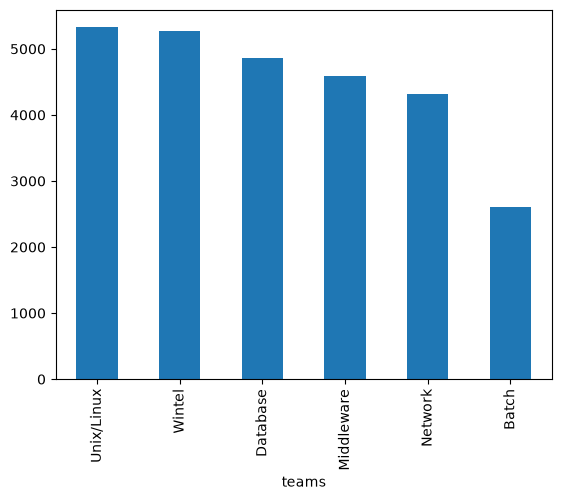

In [4]:
team_counts = (
    df["teams"]
    .str.split(",")
    .explode()
    .value_counts()
)
import matplotlib.pyplot as plt
team_counts.plot.bar()

<Axes: xlabel='priority', ylabel='count'>

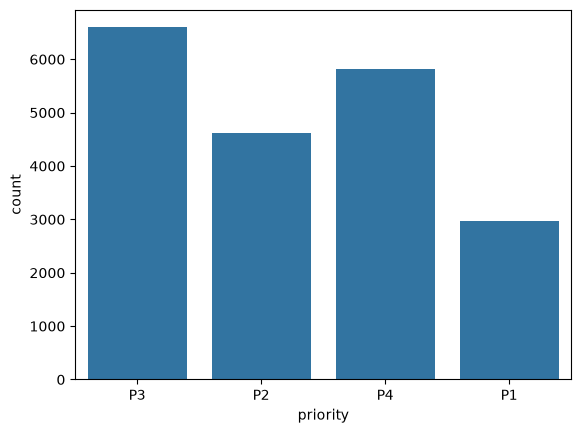

In [5]:
df["priority"].value_counts(normalize=True)*100
import seaborn as sns
sns.countplot(data=df,x="priority")

In [6]:
df["resolution_time"].describe()

count    20000.000000
mean       132.713400
std        142.332229
min          4.000000
25%         41.000000
50%         82.000000
75%        168.000000
max        780.000000
Name: resolution_time, dtype: float64

132.7134
82.0
485.0499999999993


<Axes: xlabel='resolution_time', ylabel='Count'>

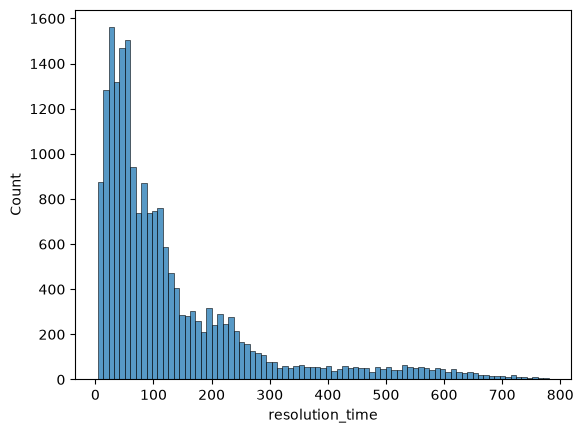

In [7]:
print(df["resolution_time"].mean()) 
print(df["resolution_time"].median())
print(df["resolution_time"].quantile(.95))
sns.histplot(df["resolution_time"])

In [8]:
df.groupby("priority")["resolution_time"].mean()

priority
P1    403.838057
P2    166.281730
P3     73.872024
P4     34.568948
Name: resolution_time, dtype: float64

In [9]:
team_exploded = (
    df.assign(
        team=df["teams"].str.split(",")
    )
    .explode("team")
)
team_exploded.groupby("team")[
    "resolution_time"
].mean()

team
Batch         107.661810
Database      180.675298
Middleware    133.645520
Network       135.275406
Unix/Linux    124.340026
Wintel        105.578698
Name: resolution_time, dtype: float64

<Axes: xlabel='application'>

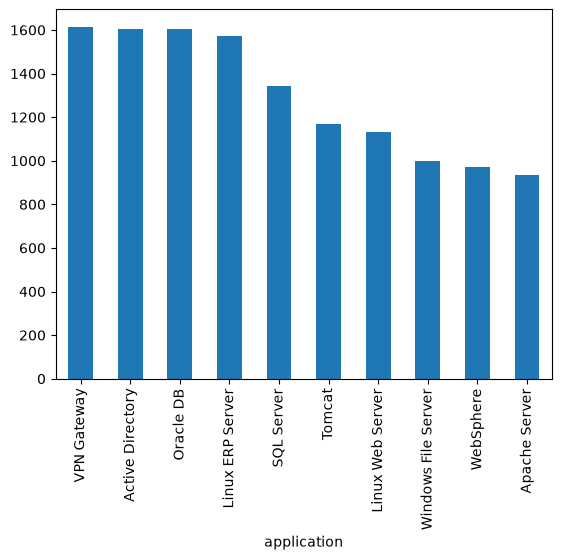

In [10]:
top = df["application"].value_counts().head(10)
top.plot.bar()


In [11]:
df["root_cause"].value_counts()

root_cause
Active Directory Failure     1750
DNS Service Failure          1663
Account Lockout              1615
Network Congestion           1364
Firewall Misconfiguration    1346
VPN Tunnel Failure           1267
Middleware Service Down      1122
Thread Pool Exhaustion       1049
Message Queue Failure        1043
Listener Failure              890
Memory Exhaustion             887
Slow Query Execution          874
Kernel Panic                  868
Database Lock                 855
Filesystem Full               832
CPU Saturation                809
ETL Failure                   598
Scheduler Failure             593
Batch Timeout                 575
Name: count, dtype: int64

In [12]:
df["created_at"] = pd.to_datetime(
    df["created_at"]
)

<Axes: xlabel='month'>

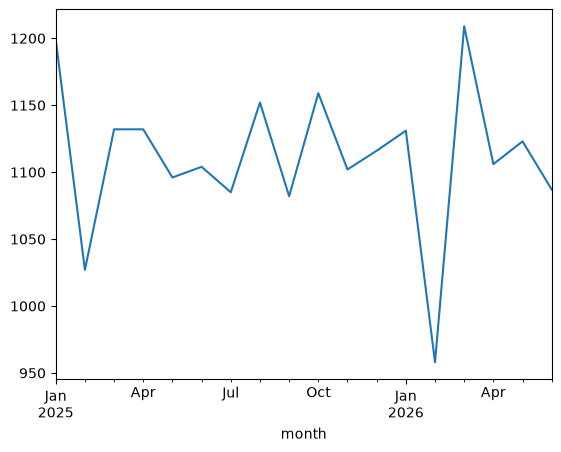

In [13]:
df["month"] = (
    df["created_at"]
    .dt.to_period("M")
)
monthly = (
    df.groupby("month")
      .size()
)
monthly.plot.line()

In [14]:
df.groupby("priority")[
    "affected_users"
].mean()

priority
P1    3921.071525
P2     371.122811
P3      41.586202
P4       4.872937
Name: affected_users, dtype: float64

In [15]:
df.groupby("priority")[
    "resolution_time"
].mean()

priority
P1    403.838057
P2    166.281730
P3     73.872024
P4     34.568948
Name: resolution_time, dtype: float64

In [16]:
pd.crosstab(
    df.environment,
    df.priority
)

priority,P1,P2,P3,P4
environment,,,,
Development,305,467,658,568
Production,2102,3262,4635,4052
UAT,557,896,1302,1196


In [17]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

df = pd.read_csv("D:\TicketingPlatform\data\synthetic_tickets.csv")

X = df["description"]
y = df["priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2)
    )),
    ("clf", LogisticRegression(
        max_iter=1000
    ))
])

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report\n")
print(classification_report(y_test, pred))
print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, pred))

Accuracy: 0.788

Classification Report

              precision    recall  f1-score   support

          P1       0.95      0.74      0.83       593
          P2       0.76      0.74      0.75       925
          P3       0.76      0.72      0.74      1319
          P4       0.78      0.92      0.85      1163

    accuracy                           0.79      4000
   macro avg       0.81      0.78      0.79      4000
weighted avg       0.79      0.79      0.79      4000


Confusion Matrix

[[ 440  153    0    0]
 [  22  682  221    0]
 [   0   61  956  302]
 [   0    0   89 1074]]


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score
df = pd.read_csv("D:\TicketingPlatform\data\synthetic_tickets.csv")
df["teams"] = df["teams"].apply(
    lambda x: x.split(",")
)
mlb = MultiLabelBinarizer()

Y = mlb.fit_transform(df["teams"])

X_train, X_test, y_train, y_test = train_test_split(
    df["description"],
    Y,
    test_size=0.2,
    random_state=42
)

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=5000,
            ngram_range=(1,2)
        )
    ),
    (
        "clf",
        OneVsRestClassifier(
            LogisticRegression(max_iter=1000)
        )
    )
])

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(
    "Micro F1:",
    f1_score(
        y_test,
        pred,
        average="micro"
    )
)

print(
    "Macro F1:",
    f1_score(
        y_test,
        pred,
        average="macro"
    )
)

Micro F1: 0.8500690681117841
Macro F1: 0.8398361786486719


In [19]:
import pandas as pd

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

df = pd.read_csv(
    "D:\TicketingPlatform\data\synthetic_tickets.csv"
)

X = df[
    [
        "description",
        "priority",
        "application"
    ]
]

y = df["resolution_time"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

preprocessor = ColumnTransformer([
    (
        "text",
        TfidfVectorizer(max_features=5000),
        "description"
    ),
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        [
            "priority",
            "application"
        ]
    )
])

model = Pipeline([
    ("prep", preprocessor),
    (
        "rf",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )
    )
])

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        pred
    )
)

MAE: 48.01180847399127
R2: 0.7113810137489313
